In [1]:
import pandas as pd
import numpy as np



In [10]:
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')

In [11]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nHead:")
print(df.head())

#DATA TYPES
print("\nData Types:")
print(df.dtypes)

#MISSING VALUES
print("\nMissing Values:")
print(df.isnull().sum())

#DUPLICATES
print("\nDuplicate Rows:", df.duplicated().sum())

#BASIC STATS (NUMERIC)
print("\nSummary Stats:")
print(df.describe())

#TARGET DISTRIBUTION
print("\nChurn Distribution (counts):")
print(df['churn'].value_counts())
print("\nChurn Distribution (proportions):")
print(df['churn'].value_counts(normalize=True))

#DROP IRRELEVANT COLUMNS
df = df.drop(columns=['customer_id'])

# CHECK CATEGORICAL VALUES
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

Shape: (10000, 12)

Columns:
 Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

Head:
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            

In [ ]:
# DEFINING FEATURES and TARGET
X = df.drop(columns=['churn'])
y = df['churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

# IDENTIFY COLUMN TYPES
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)



# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)



# CHECK TARGET DISTRIBUTION AFTER SPLIT
print("\nTrain churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True))

X shape: (10000, 10)
y shape: (10000,)

Categorical columns: ['country', 'gender']
Numeric columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

Train shape: (8000, 10)
Test shape: (2000, 10)

Train churn distribution:
churn
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Test churn distribution:
churn
0    0.7965
1    0.2035
Name: proportion, dtype: float64


In [12]:
# PREPROCESSING PIPELINE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)


# MODEL PIPELINE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])



# FIT MODEL
model.fit(X_train, y_train)



# PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]



# BASIC OUTPUT CHECK
print("\nPredicted probabilities:")
print(y_prob[:10])

print("\n10 predictions:")
print(y_pred[:10])


Predicted probabilities:
[0.31740441 0.57613846 0.35031209 0.3806209  0.30207278 0.35091549
 0.27484036 0.65919994 0.67451318 0.49678314]

10 predictions:
[0 1 0 0 0 0 0 1 1 0]


In [13]:
# BASIC METRICS
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    brier_score_loss
)

roc_auc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_prob)

print("ROC AUC:", roc_auc)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Brier Score:", brier)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# PRECISION @ TOP 20%
results = pd.DataFrame({
    'y_true': y_test,
    'y_prob': y_prob
})

results = results.sort_values(by='y_prob', ascending=False)

top_20_pct = int(0.2 * len(results))
top_20 = results.head(top_20_pct)

precision_top_20 = top_20['y_true'].mean()

print("\nPrecision @ Top 20%:", precision_top_20)

# LIFT @ TOP 10%
top_10_pct = int(0.1 * len(results))
top_10 = results.head(top_10_pct)

baseline_rate = results['y_true'].mean()
lift_top_10 = top_10['y_true'].mean() / baseline_rate

print("Baseline churn rate:", baseline_rate)
print("Lift @ Top 10%:", lift_top_10)

ROC AUC: 0.7771824212502177
Accuracy: 0.714
Precision: 0.3877551020408163
Recall: 0.7002457002457002
Brier Score: 0.19419264922077897

Confusion Matrix:
[[1143  450]
 [ 122  285]]

Precision @ Top 20%: 0.4975
Baseline churn rate: 0.2035
Lift @ Top 10%: 2.530712530712531


The baseline logistic regression model achieved a ROC AUC of 0.777, indicating a reasonable ability to distinguish between customers who churn and those who do not. While overall accuracy was 0.714, this metric is less informative due to class imbalance. The model achieved a recall of 0.700, meaning it successfully identified a majority of churners, although precision was lower at 0.388, indicating a higher number of false positives.

From a business perspective, the model performs more strongly when used for ranking. The top 20% highest-risk customers had a churn rate of approximately 0.498, more than double the baseline churn rate of 0.2035. Similarly, the lift at the top 10% was 2.53, meaning these customers were over 2.5 times more likely to churn than average. Overall, while the model is not highly precise, it is effective for prioritizing high-risk customers and is sufficient as a baseline for the MVP.

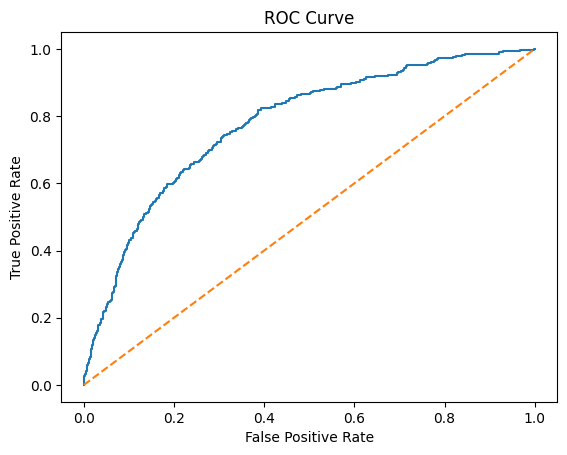

In [ ]:

# ROC CURVE

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

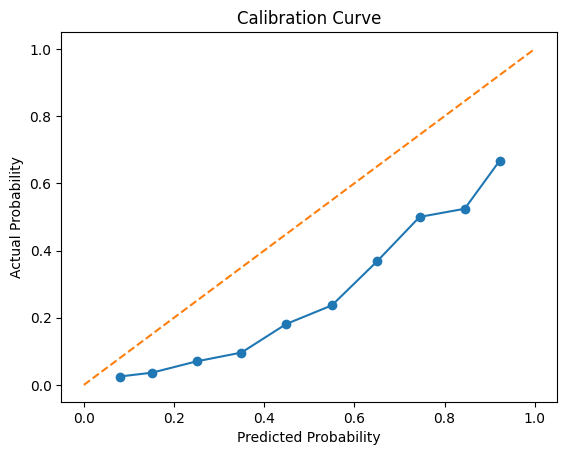

In [ ]:

# CALIBRATION CURVE

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.show()


Top Positive Features (increase churn risk):
            feature  coefficient
8   country_Germany     0.821611
1               age     0.801686
3           balance     0.176266
9     country_Spain     0.056181
7  estimated_salary     0.050707
2            tenure    -0.018738
5       credit_card    -0.031723
4   products_number    -0.057934
0      credit_score    -0.087368
6     active_member    -0.442143

Top Negative Features (reduce churn risk):
             feature  coefficient
1                age     0.801686
3            balance     0.176266
9      country_Spain     0.056181
7   estimated_salary     0.050707
2             tenure    -0.018738
5        credit_card    -0.031723
4    products_number    -0.057934
0       credit_score    -0.087368
6      active_member    -0.442143
10       gender_Male    -0.547493


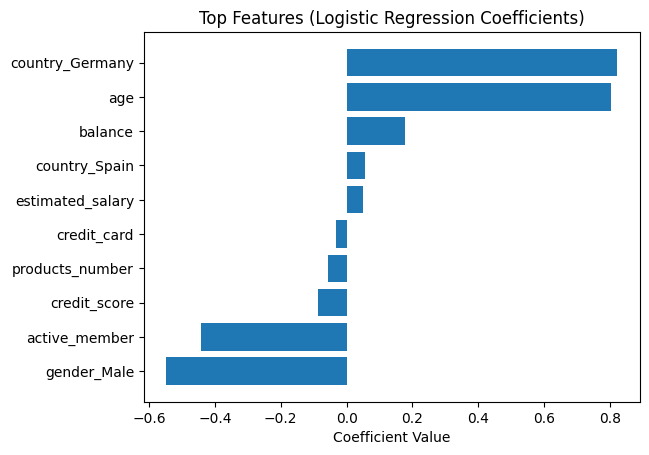

In [ ]:

# EXTRACT FEATURE NAMES

# get feature names after preprocessing

ohe = model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

feature_names = numeric_cols + list(encoded_cat_cols)



# GET COEFFICIENTS

coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df = coef_df.sort_values(by='coefficient', ascending=False)

print("\nTop Positive Features (increase churn risk):")
print(coef_df.head(10))

print("\nTop Negative Features (reduce churn risk):")
print(coef_df.tail(10))



# PLOT TOP FEATURES

top_features = pd.concat([coef_df.head(5), coef_df.tail(5)])

plt.figure()
plt.barh(top_features['feature'], top_features['coefficient'])
plt.title("Top Features (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.show()

ROC curve shows that model performs substantially better than random classification, consistent with the AUC of 0.777. The calibration curve indicates that predicted probabilities tend to overestimate actual churn risk, suggesting that while probability estimates are not perfectly calibrated, the model remains effective for ranking customers.

From the coefficient analysis, age and being located in Germany are the strongest predictors of increased churn risk. Higher account balance is also associated with higher churn probability. In contrast, active membership and being male are associated with lower churn risk. These results are consistent with earlier exploratory findings and provide interpretable insights into customer behavior.

In [17]:
import joblib

joblib.dump(model, '../models/logistic_model.pkl')

['../models/logistic_model.pkl']